In [71]:
import pandas as pd 
import sys 
sys.path.append("/workspace/")
from src.metrics import ClinicalQAEvaluator
from glob import glob  

# result_root_dir = "/workspace/kor_med_opendataset/results/snuh_ClinicalQA_benchmark" # ClinicalQA
result_root_dir = "/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/pharm" # KorMedMCQA
# result_root_dir = "/workspace/kor_med_opendataset/results/aihub_전문_의학지식_데이터_benchmark/객관식" # aihub_전문의학지식데이터 객관식
# result_root_dir = "/workspace/kor_med_opendataset/results/aihub_필수의료_의학지식_데이터_benchmark/객관식" # aihub_필수의료의학지식데이터 객관식

save_result_dir = "/workspace/benchmark"

In [72]:
from IPython.display import display
import os 
parquet_files = glob(f"{result_root_dir}/**/*.parquet", recursive=False)

all_summary_df = pd.DataFrame()
for parquet_file in parquet_files:
    model_name = parquet_file.split('/')[-2]
    evaluator = ClinicalQAEvaluator(parquet_file)

    # 성능 요약
    summary_df = evaluator.summary()
    
    # 맨 앞에 모델명 붙히기
    summary_df.insert(0, 'model', model_name)
    
    all_summary_df = pd.concat([all_summary_df, summary_df])
    
all_summary_df = all_summary_df.sort_values("accuracy (%)", ascending=True)
# all_summary_df.to_csv(f"{result_root_dir}/all_summary.csv", index=False)

display(all_summary_df)

,model,total_samples,correct_predictions,accuracy (%),avg_first_token_latency (s),avg_time_per_token (s),avg_vram_usage (MB),mean_flops,mean_flops_per_token,mean_cost_per_token (s)
0,meta-llama_Llama-3_2-1B-Instruct,1049,263,25.07,0.656814,0.006016,0.000000,8.401441e+11,7.414886e+09,0.006016
0,google_gemma-3-1b-it,1816,465,25.61,2.066813,0.012329,0.000000,1.004641e+12,5.999316e+09,0.012329
0,Qwen_Qwen3-0_6B,1815,532,29.31,0.781803,0.009339,0.000000,3.012801e+11,3.576300e+09,0.009339
0,naver-hyperclovax_HyperCLOVAX-SEED-Text-Instru...,733,248,33.83,1.173674,0.011613,229.422493,3.862610e+11,3.397687e+09,0.011613
0,naver-hyperclovax_HyperCLOVAX-SEED-Text-Instru...,1256,435,34.63,1.195910,0.010391,263.517914,1.156326e+12,9.513284e+09,0.010391
0,Qwen_Qwen3-1_7B,1817,804,44.25,1.398076,0.010210,0.000000,1.417335e+12,1.032345e+10,0.010210
0,meta-llama_Llama-3_2-3B-Instruct,1726,784,45.42,1.070722,0.010293,266.066049,2.054656e+12,1.927650e+10,0.010293
0,LGAI-EXAONE_EXAONE-4_0-1_2B,1635,789,48.26,0.190703,0.009549,158.703364,1.534096e+11,7.676349e+09,0.009549
0,google_gemma-3-4b-it,1817,910,50.08,2.995983,0.018820,0.000000,4.111804e+12,2.580048e+10,0.018820
0,meta-llama_Meta-Llama-3-8B-Instruct,1803,938,52.02,1.699569,0.019674,746.915141,4.170151e+12,4.818157e+10,0.019674


In [73]:
# 모델명을 '_'로 분리해 그룹(시리즈)와 이름을 분리해서, 시리즈(group)별로 accuracy 오름차순 정렬해서 보여주기
df_temp = all_summary_df.copy()
df_temp['model_group'] = df_temp['model'].apply(lambda x: x.split('_')[0])
df_temp['model_name'] = df_temp['model'].apply(lambda x: '_'.join(x.split('_')[1:]))

df_temp['mean_flops (GFlops)'] = (df_temp['mean_flops'] / 1e9).round(3)
df_temp['accuracy (%)'] = df_temp['accuracy (%)'].round(3)
df_temp['avg_time_per_token (s)'] = df_temp['avg_time_per_token (s)'].round(3)

display_cols = ['model_group', 'model_name', 'accuracy (%)', 'avg_time_per_token (s)', 'mean_flops (GFlops)']
# model_group별로 accuracy 오름차순 정렬
df_temp = df_temp.sort_values(['model_group', 'accuracy (%)'], ascending=[True, True])
display(df_temp[display_cols])
# csv로 저장
df_temp[display_cols].to_csv(f"{save_result_dir}/{result_root_dir.split('/')[-1]}.csv", index=False)

# markdown으로도 저장
with open(f"{save_result_dir}/{result_root_dir.split('/')[-1]}.md", "w", encoding="utf-8") as f:
    # 헤더
    f.write("| " + " | ".join(display_cols) + " |\n")
    f.write("|" + "----|" * len(display_cols) + "\n")
    # 행 내용
    for _, row in df_temp[display_cols].iterrows():
        f.write("| " + " | ".join(str(x) for x in row.values) + " |\n")


,model_group,model_name,accuracy (%),avg_time_per_token (s),mean_flops (GFlops)
0,K-intelligence,Midm-2_0-Mini-Instruct,56.01,0.024,874.654
0,K-intelligence,Midm-2_0-Base-Instruct,70.88,0.203,5814.452
0,LGAI-EXAONE,EXAONE-4_0-1_2B,48.26,0.010,153.410
0,LGAI-EXAONE,EXAONE-3_5-2_4B-Instruct,52.11,0.009,288.598
0,LGAI-EXAONE,EXAONE-3_5-7_8B-Instruct,62.52,0.020,938.214
0,Qwen,Qwen3-0_6B,29.31,0.009,301.280
0,Qwen,Qwen3-1_7B,44.25,0.010,1417.335
0,Qwen,Qwen3-4B-Instruct-2507,67.53,0.017,5095.545
0,Qwen,Qwen3-8B,69.51,0.026,7435.276
0,google,gemma-3-1b-it,25.61,0.012,1004.641


✔ Saved to: /workspace/benchmark/객관식.png


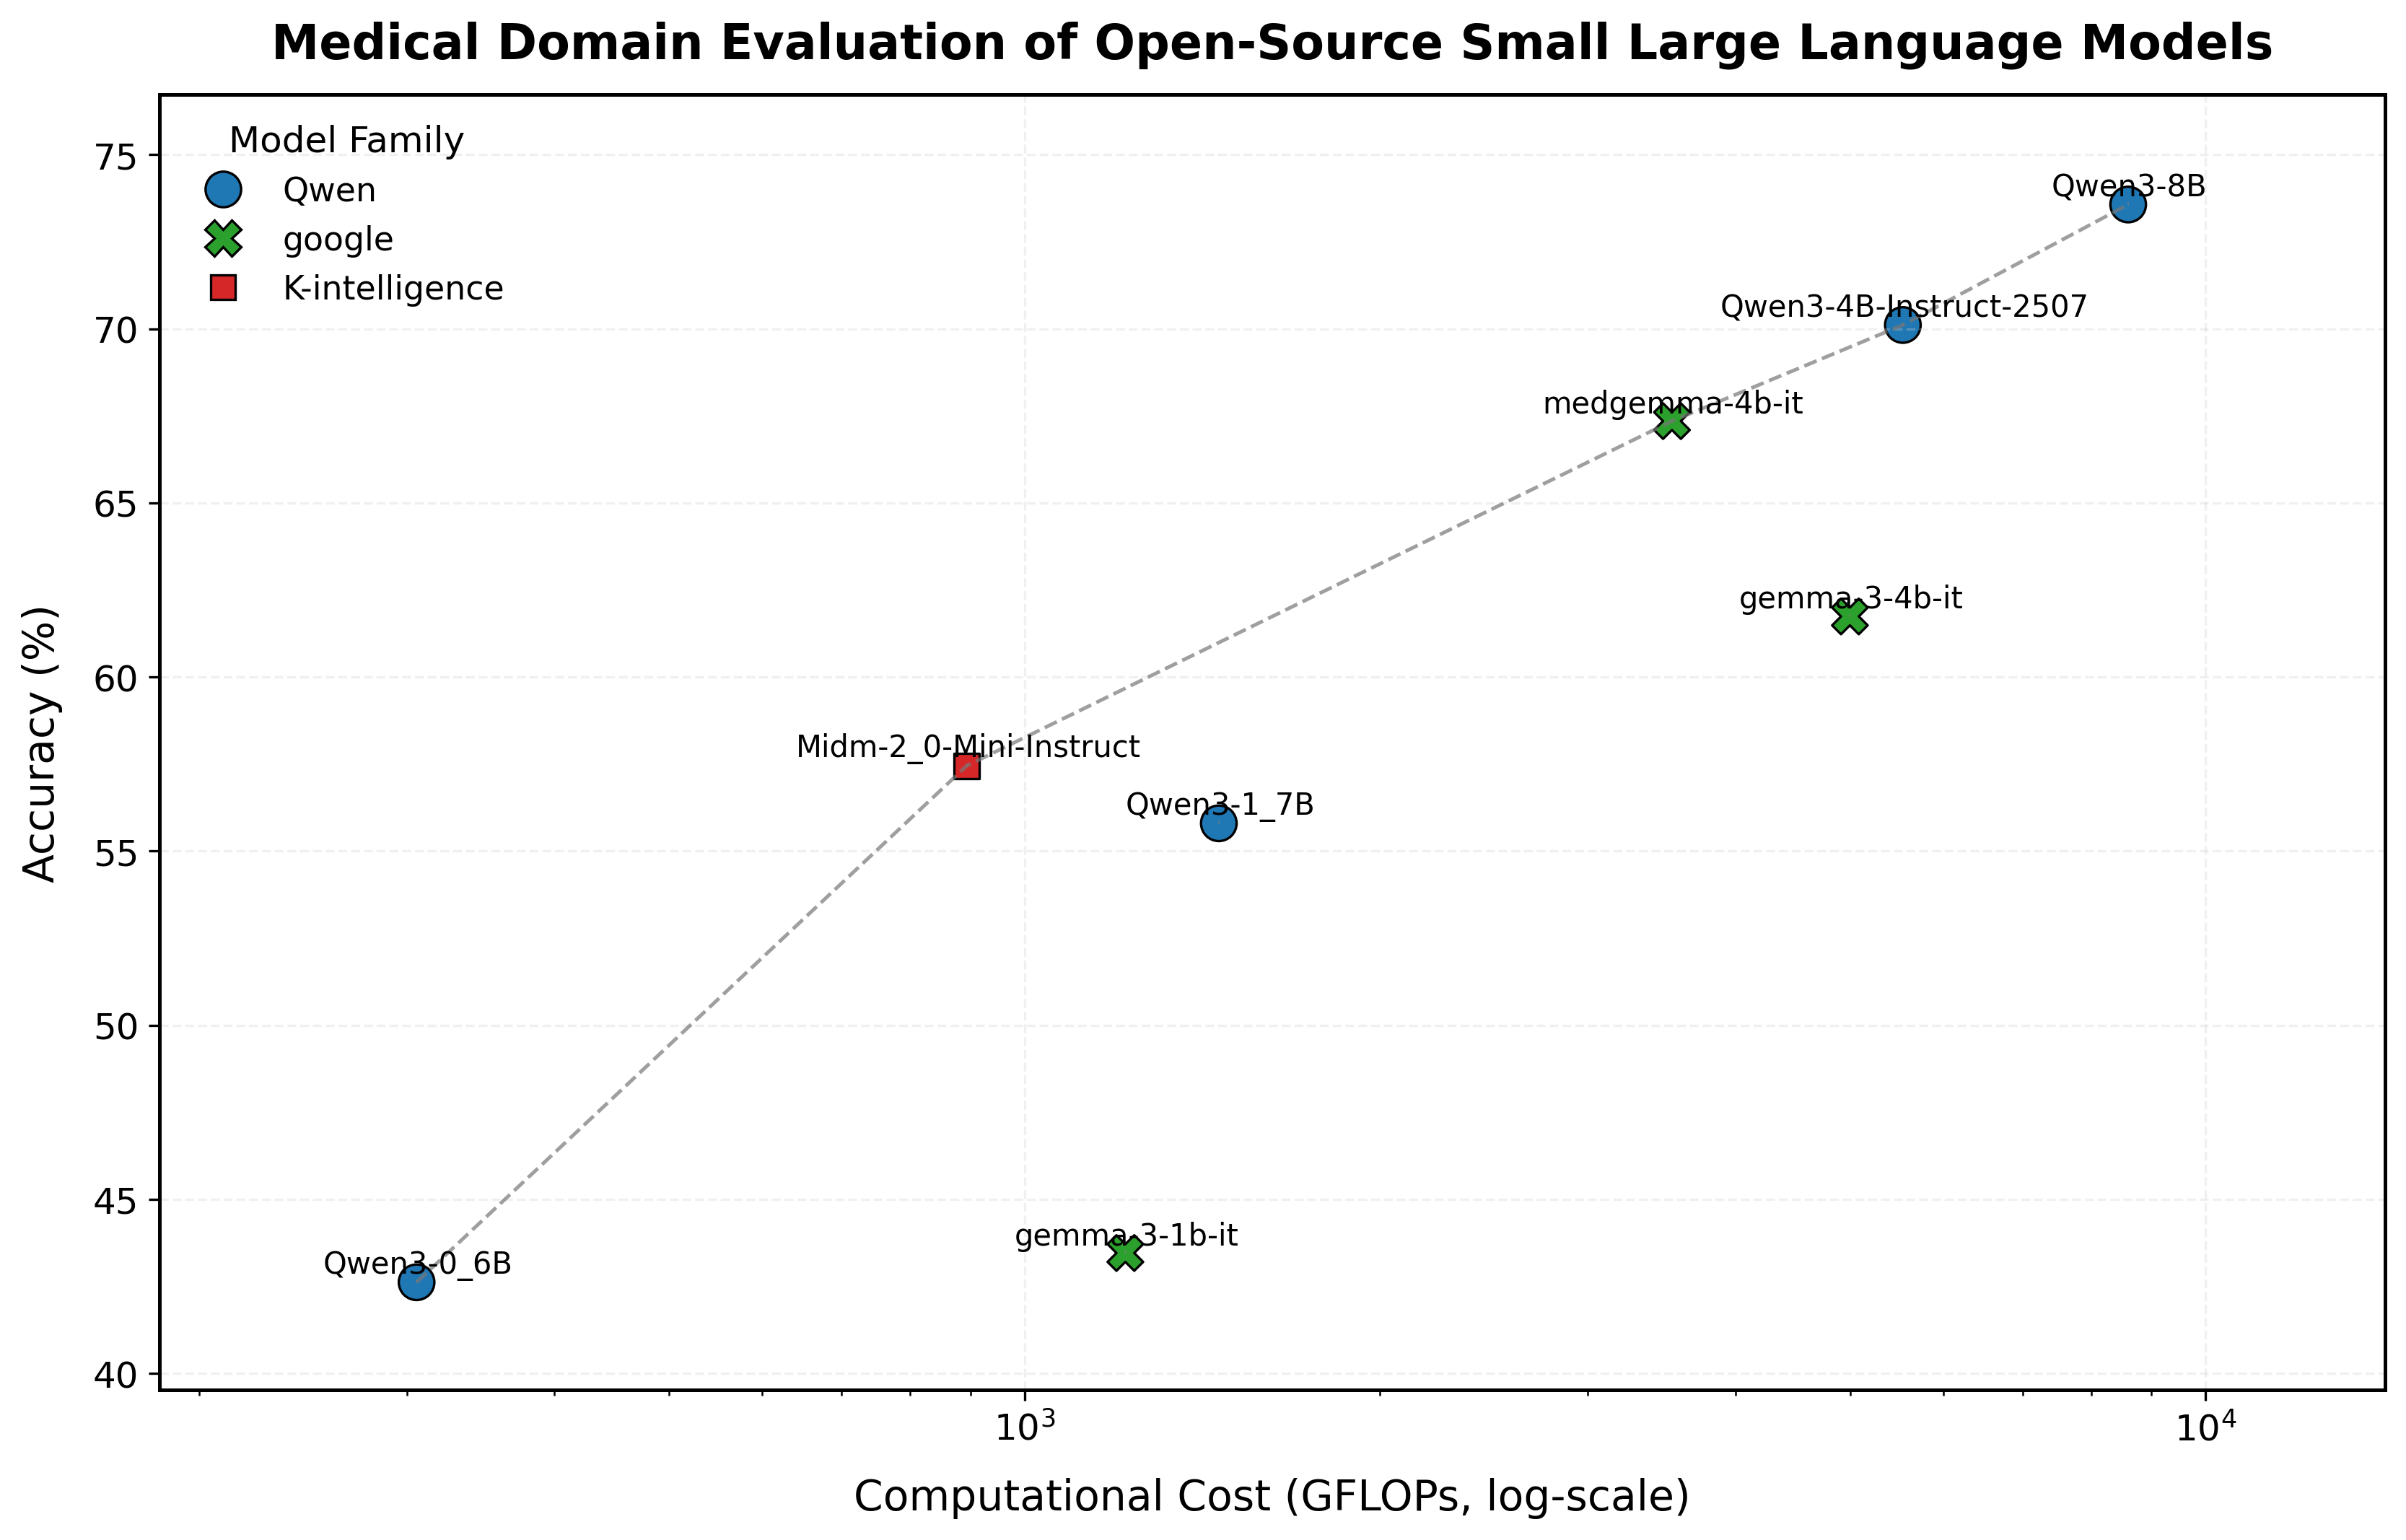

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# adjustText 있는지 체크
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False

# ---------------------------------------------------------
# NEJM / Nature 스타일 시각화 테마
# ---------------------------------------------------------
def set_nature_style():
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "grid.color": "#d0d0d0",
        "grid.linewidth": 0.8,
        "grid.linestyle": "--",
        "figure.dpi": 300
    })

# ---------------------------------------------------------
# Nature/NEJM 스타일 플롯 함수 (팔레트 오류 방지)
# ---------------------------------------------------------
def plot_medical_llm_benchmark_nature(
    df,
    x_col='mean_flops',
    y_col='accuracy (%)',
    model_col='model',
    figsize=(11, 7),
    dpi=300,
    title="Medical Domain Evaluation of Open-Source Small Large Language Models",
    save_path="NEJM_style_plot.png"
):
    set_nature_style()
    
    # 데이터 준비
    plot_df = df.copy()
    plot_df[x_col] = plot_df[x_col] / 1e9
    plot_df["Group"] = plot_df[model_col].apply(lambda x: x.split("_")[0])
    plot_df["Short Name"] = plot_df[model_col].apply(lambda x: "_".join(x.split("_")[1:]))

    # Group 유니크값 확인
    unique_groups = plot_df["Group"].unique()
    # 컬러 팔레트 준비 (유니크값만큼 할당)
    palette_colors = [
        "#1f77b4", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#17becf",
        "#ff7f0e", "#bcbd22", "#e377c2", "#7f7f7f", "#aec7e8", "#ffbb78"
    ]
    palette = {g: c for g, c in zip(unique_groups, palette_colors)}

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, constrained_layout=True)

    # Pareto frontier 계산
    sorted_df = plot_df.sort_values(by=x_col)
    pareto_points = []
    current_max = -np.inf
    for _, row in sorted_df.iterrows():
        if row[y_col] > current_max:
            pareto_points.append((row[x_col], row[y_col]))
            current_max = row[y_col]

    # Pareto frontier 표시 (NEJM식: 얇고 연한 회색선)
    if len(pareto_points) > 0:
        px, py = zip(*pareto_points)
        ax.plot(px, py, "--", color="#777777", linewidth=1.2, alpha=0.7)

    # Scatter plot (NEJM 스타일: 단색·단순)
    sns.scatterplot(
        data=plot_df,
        x=x_col, y=y_col,
        hue="Group", palette=palette,
        style="Group",
        markers=True,
        s=140, edgecolor="black", linewidth=0.8,
        ax=ax
    )

    # axes 설정
    ax.set_xscale("log")
    ax.set_xlabel("Computational Cost (GFLOPs, log-scale)", fontsize=14, labelpad=10)
    ax.set_ylabel("Accuracy (%)", fontsize=14, labelpad=10)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=12)

    # Grid 스타일: NEJM/Nature = subtle
    ax.grid(True, alpha=0.3)
    
    # Legend (최소한으로)
    ax.legend(title="Model Family", frameon=False, fontsize=11, title_fontsize=12)

    # Annotation (Short Name)
    texts = []
    for _, row in plot_df.iterrows():
        t = ax.text(
            row[x_col], row[y_col],
            row["Short Name"],
            fontsize=10,
            color="black",
            ha="center", va="bottom"
        )
        texts.append(t)

    # 텍스트 겹침 제거
    if HAS_ADJUST_TEXT:
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6),
            force_text=(0.3, 0.4)
        )

    # 마진 보정
    ax.margins(x=0.15, y=0.1)

    # 저장
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✔ Saved to: {save_path}")

    plt.show()


# ---------------------------------------------------------
# 실행
# ---------------------------------------------------------
plot_medical_llm_benchmark_nature(all_summary_df, save_path=f"{save_result_dir}/{result_root_dir.split('/')[-1]}.png")

### 전체 다됫는지 검수

In [1]:
from glob import glob 
import os 

snuh_clinical_qa_dir = "/workspace/kor_med_opendataset/results/snuh_ClinicalQA_benchmark"
def check_parquet_files(dir_path):
    snuh_clinical_qa_list = []
    for model_dir in os.listdir(dir_path):
        if os.path.isdir(os.path.join(dir_path, model_dir)):
            for file in os.listdir(os.path.join(dir_path, model_dir)):
                if file.endswith(".parquet"):
                    snuh_clinical_qa_list.append(os.path.join(snuh_clinical_qa_dir, model_dir, file))
    return snuh_clinical_qa_list

print("--------------------------------")
print("snuh_ClinicalQA")
print("snuh_ClinicalQA_benchmark : ",len(check_parquet_files(dir_path = "/workspace/kor_med_opendataset/results/snuh_ClinicalQA_benchmark")))
print("--------------------------------")
print("Sean0042_KorMedMCQA")
print("sean0042_KorMedMCQA_benchmark - Doctor: ",len(check_parquet_files(dir_path = "/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/doctor")))
print("sean0042_KorMedMCQA_benchmark - Nurse: ",len(check_parquet_files(dir_path = "/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/nurse")))
print("sean0042_KorMedMCQA_benchmark - Dentist: ",len(check_parquet_files(dir_path = "/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/dentist")))
print("sean0042_KorMedMCQA_benchmark - Pharmacist: ",len(check_parquet_files(dir_path = "/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/pharm")))
print("--------------------------------")
print("aihub_전문_의학지식_데이터_benchmark : ",len(check_parquet_files(dir_path = "/workspace/kor_med_opendataset/results/aihub_전문_의학지식_데이터_benchmark/객관식")))
print("--------------------------------")
print("aihub_필수의료_의학지식_데이터_benchmark : ",len(check_parquet_files(dir_path = "/workspace/kor_med_opendataset/results/aihub_필수의료_의학지식_데이터_benchmark/객관식")))

--------------------------------
snuh_ClinicalQA
snuh_ClinicalQA_benchmark :  23
--------------------------------
Sean0042_KorMedMCQA
sean0042_KorMedMCQA_benchmark - Doctor:  23
sean0042_KorMedMCQA_benchmark - Nurse:  23
sean0042_KorMedMCQA_benchmark - Dentist:  23
sean0042_KorMedMCQA_benchmark - Pharmacist:  23
--------------------------------
aihub_전문_의학지식_데이터_benchmark :  22
--------------------------------
aihub_필수의료_의학지식_데이터_benchmark :  8


## snuh_ClinicalQA 카테고리별 분석

가중 평균 기준 최고 모델: K-intelligence_Midm-2_0-Base-Instruct (66.00%)
가장 평균적으로 정확도가 높은 모델: K-intelligence_Midm-2_0-Base-Instruct
29


/tmp/ipykernel_460894/11326603.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["accuracy"], weights=x["n_samples"]))


,category,n_samples,accuracy (%)
228,Radiology,1,0.000
211,General Surgery,58,48.276
231,Vascular Surgery,2,50.000
214,Hematology and Oncology,48,50.000
213,Gynecology,70,51.429
229,Rheumatology,49,53.061
217,Nephrology,111,54.955
203,Allergy and Immunology,36,58.333
205,Dermatology,12,66.667
207,Endocrinology,68,67.647


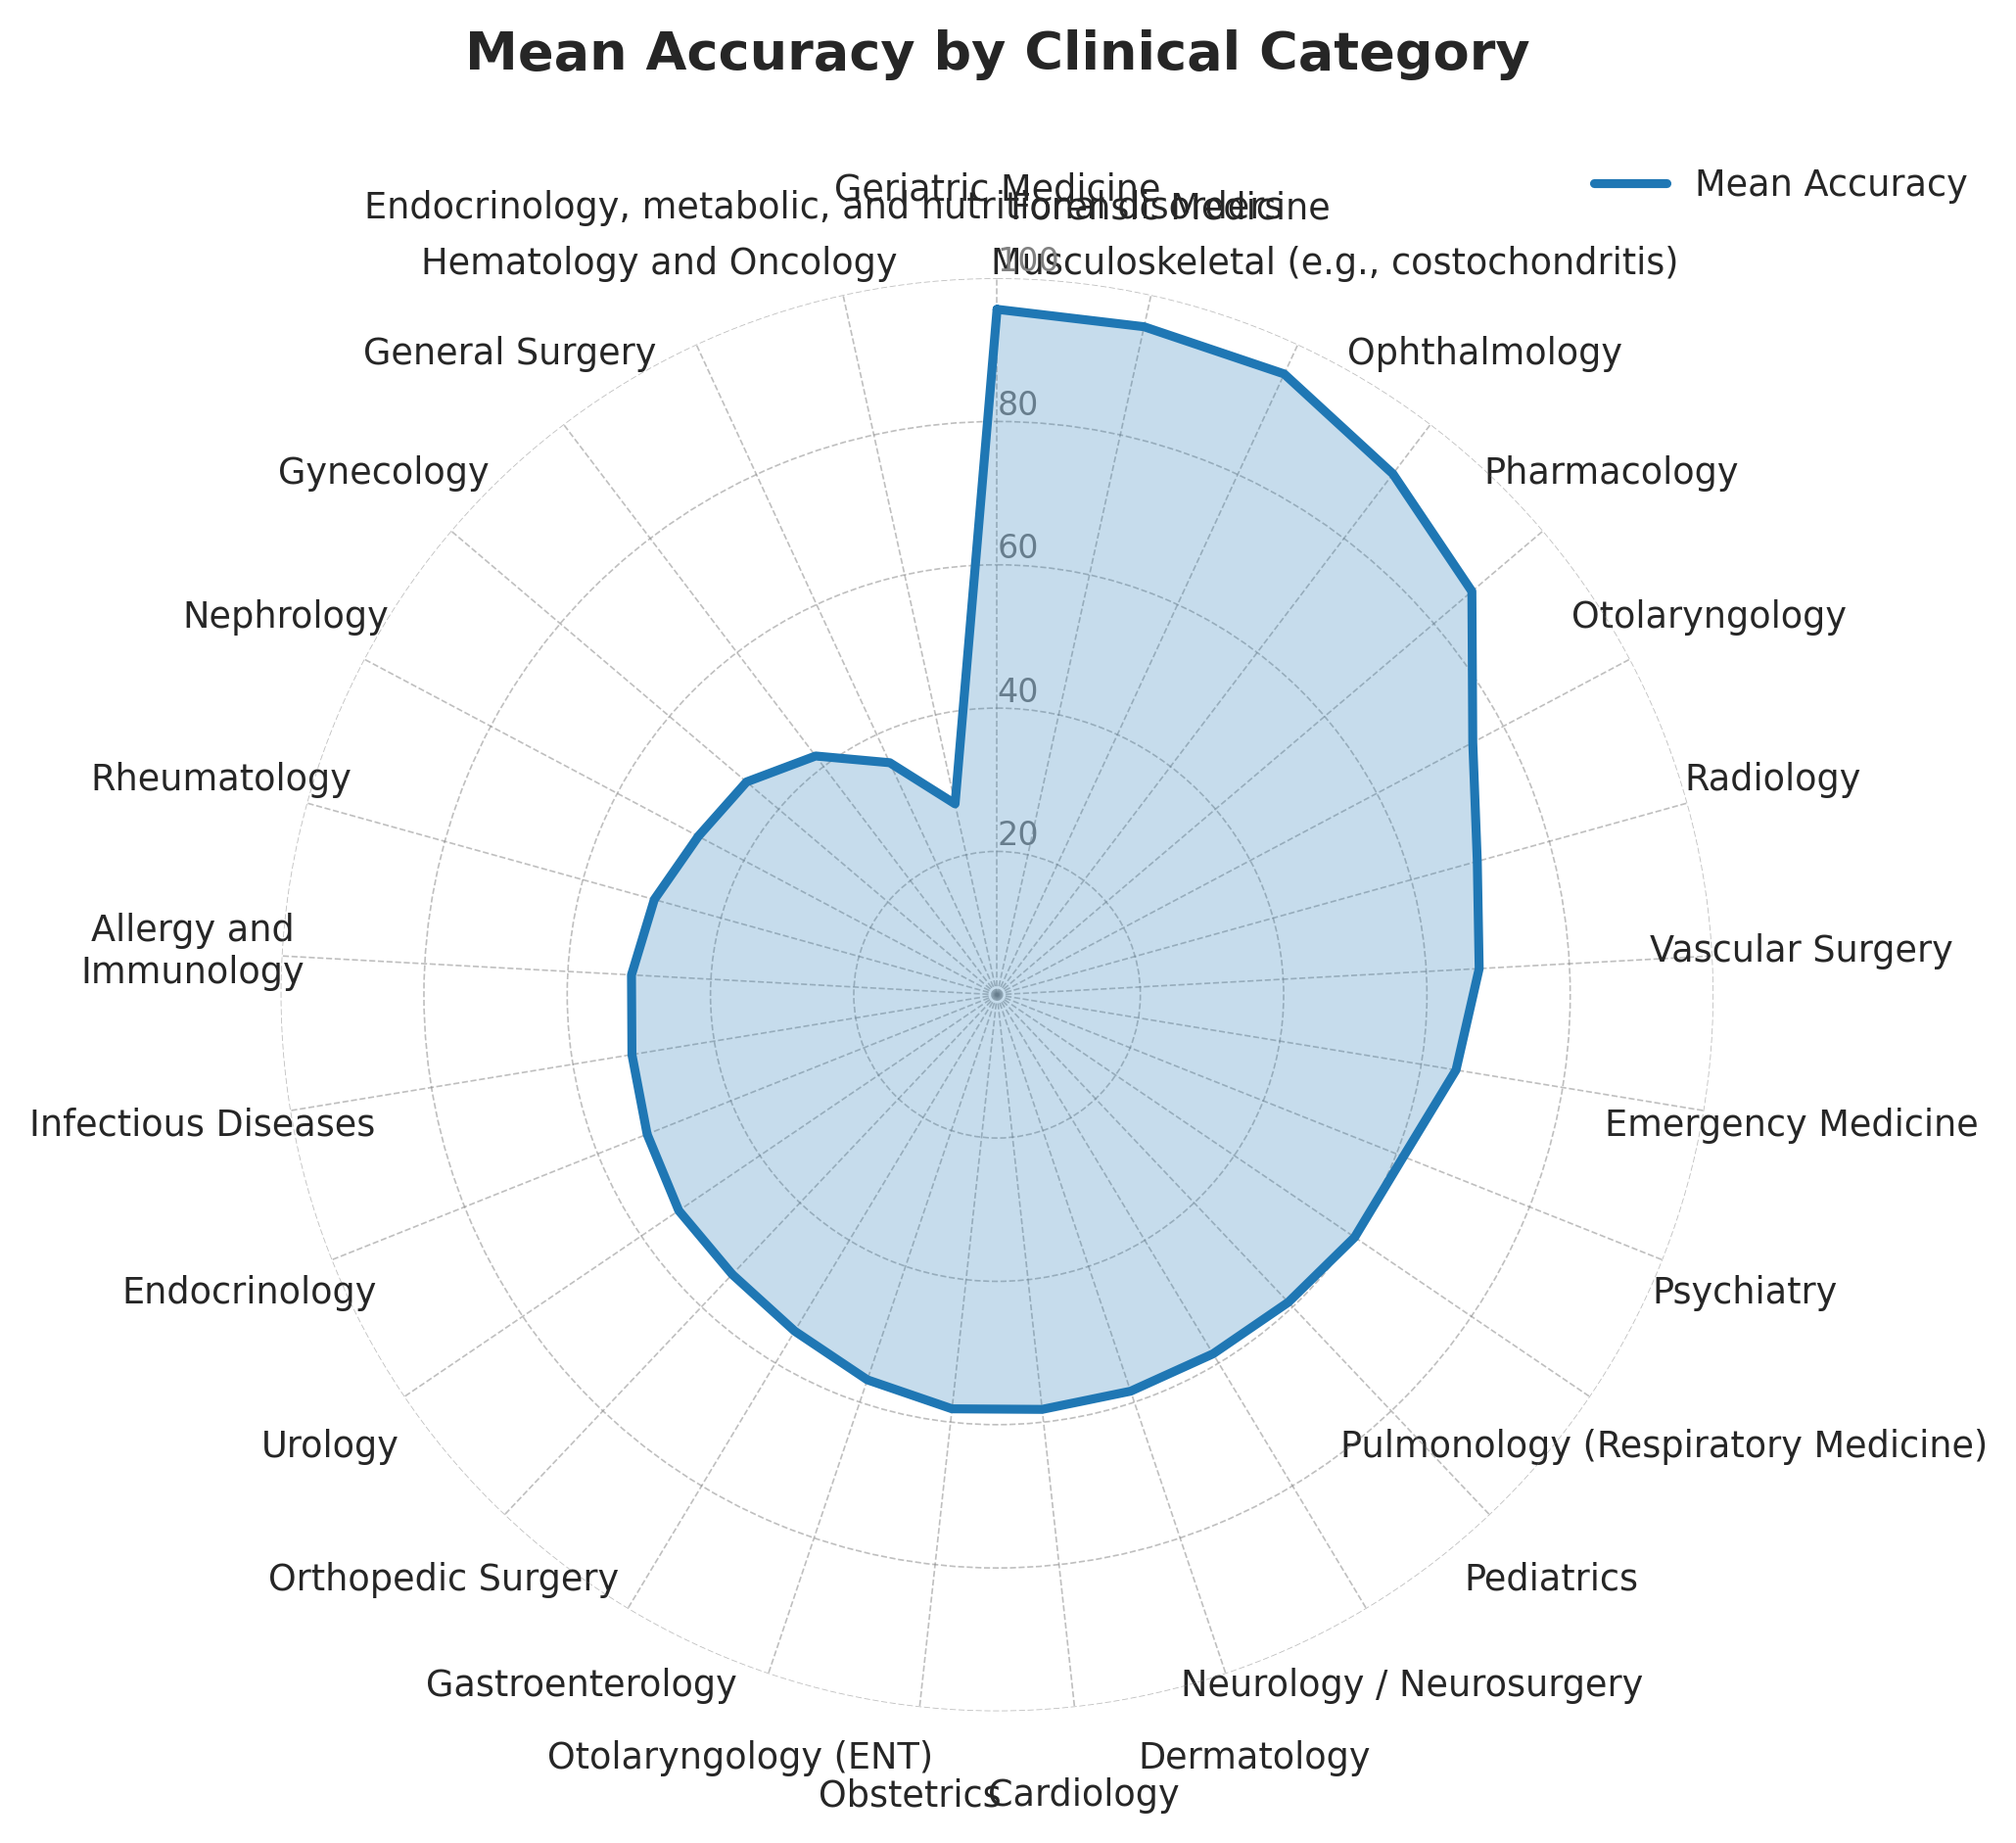

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from glob import glob
import os

# -----------------------------
# 1️⃣ 데이터 로드
# -----------------------------
df = pd.read_csv("/mnt/sdd/kor_med_opendataset/snuh_ClinicalQA/train.csv")
result_root_dir = "/workspace/kor_med_opendataset/results/snuh_ClinicalQA_benchmark"
parquet_files = glob(f"{result_root_dir}/**/*.parquet", recursive=False)

# -----------------------------
# 2️⃣ 모델별 카테고리 정확도 계산
# -----------------------------
model_category_acc_list = []

for parquet_file in parquet_files:
    model_name = parquet_file.split('/')[-2]
    pred_df = pd.read_parquet(parquet_file)

    # 정답 여부 컬럼 추가
    pred_df["is_correct"] = pred_df["pred_answer"] == pred_df["gt_answer"]

    # category 매칭 (df의 question_id 기준)
    merged_df = pd.merge(pred_df, df[["question_id", "category"]], on="question_id", how="left")

    # 카테고리별 정확도 계산
    category_acc = (
        merged_df.groupby("category")["is_correct"]
        .mean()
        .reset_index()
        .rename(columns={"is_correct": "accuracy"})
    )
    category_acc["model"] = model_name

    model_category_acc_list.append(category_acc)

# 하나의 큰 DF로 통합
acc_df = pd.concat(model_category_acc_list, ignore_index=True)
# 1️⃣ 각 category별 question 개수 계산
category_counts = df["category"].value_counts().rename_axis("category").reset_index(name="n_samples")

# 2️⃣ acc_df에 병합
acc_df = pd.merge(acc_df, category_counts, on="category", how="left")

acc_df["accuracy (%)"] = acc_df["accuracy"] * 100
# 🔹 가중 평균 기반 순위 계산
weighted_acc = (
    acc_df.groupby("model")
    .apply(lambda x: np.average(x["accuracy"], weights=x["n_samples"]))
    .reset_index(name="weighted_accuracy")
    .sort_values("weighted_accuracy", ascending=False)
)

# 🔹 상위 모델 확인
best_model = weighted_acc.iloc[0]["model"]
best_acc = weighted_acc.iloc[0]["weighted_accuracy"]

print(f"가중 평균 기준 최고 모델: {best_model} ({best_acc*100:.2f}%)")

acc_df_best = acc_df[acc_df["model"] == best_model]


print(f"가장 평균적으로 정확도가 높은 모델: {best_model}")
print(len(acc_df_best))
display(acc_df_best[['category', 'n_samples', 'accuracy (%)']].sort_values(by='accuracy (%)', ascending=True).round(3))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# -------------------------------------------------
# 1️⃣ Category별 평균 accuracy 계산
# -------------------------------------------------
acc_summary = acc_df.groupby("category")["accuracy (%)"].mean().sort_values(ascending=False)
categories = acc_summary.index.tolist()
values = acc_summary.values.tolist()

# 레이더 차트는 닫힌 형태이므로 첫 값 반복
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(categories) + 1)

# -------------------------------------------------
# 2️⃣ Nature-style 세팅
# -------------------------------------------------
sns_color = "#1f77b4"  # 블루 계열 메인 컬러
rcParams.update({
    "figure.figsize": (7, 7),
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
})

fig, ax = plt.subplots(subplot_kw=dict(polar=True))

# -------------------------------------------------
# 3️⃣ Plot
# -------------------------------------------------
ax.plot(angles, values, color=sns_color, linewidth=2.2, linestyle='solid', label="Mean Accuracy")
ax.fill(angles, values, color=sns_color, alpha=0.25)

# 축 설정
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# 각 축 라벨
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=8.8, ha='center', wrap=True)
for label in ax.get_xticklabels():
    label.set_rotation(0)  # 회전 최소화

# 반지름 축 (accuracy scale)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100],
           ["20", "40", "60", "80", "100"],
           color="gray", size=8)
plt.ylim(0, 100)

# 제목
plt.title("Mean Accuracy by Clinical Category", size=13, weight="semibold", pad=25)

# 디자인 정리
ax.spines["polar"].set_visible(False)
ax.grid(True, color="gray", linestyle="--", linewidth=0.4, alpha=0.5)
ax.tick_params(axis='x', pad=10)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), frameon=False)

plt.tight_layout()
# plt.savefig("figures/Figure_ClinicalCategory_RadarPlot_NatureStyle.pdf", dpi=600, bbox_inches="tight")
# plt.savefig("figures/Figure_ClinicalCategory_RadarPlot_NatureStyle.png", dpi=600, bbox_inches="tight", transparent=True)
plt.show()



## sean0042_KorMedMCQA 과별 분석 

In [ ]:
import pandas as pd 
import sys 
sys.path.append("/workspace/")
from src.metrics import ClinicalQAEvaluator
from glob import glob  

sean0042_root_dir = "/workspace/kor_med_opendataset/results/sean0042_KorMedMCQA_benchmark/" # KorMedMCQA

from IPython.display import display
import os 

domain_dict = {}
for domain in os.listdir(sean0042_root_dir):
    result_root_dir = f"{sean0042_root_dir}/{domain}"
    parquet_files = glob(f"{result_root_dir}/**/*.parquet", recursive=False)

    all_summary_df = pd.DataFrame()
    for parquet_file in parquet_files:
        model_name = parquet_file.split('/')[-2]
        evaluator = ClinicalQAEvaluator(parquet_file)

        # 성능 요약
        summary_df = evaluator.summary()
        
        # 맨 앞에 모델명 붙히기
        summary_df.insert(0, 'model', model_name)
        
        all_summary_df = pd.concat([all_summary_df, summary_df])
        
    all_summary_df = all_summary_df.sort_values("accuracy (%)", ascending=True)

    domain_dict[domain] = all_summary_df
    

/tmp/ipykernel_460894/4138599340.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_460894/4138599340.py:28: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_460894/4138599340.py:28: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.pointplot(


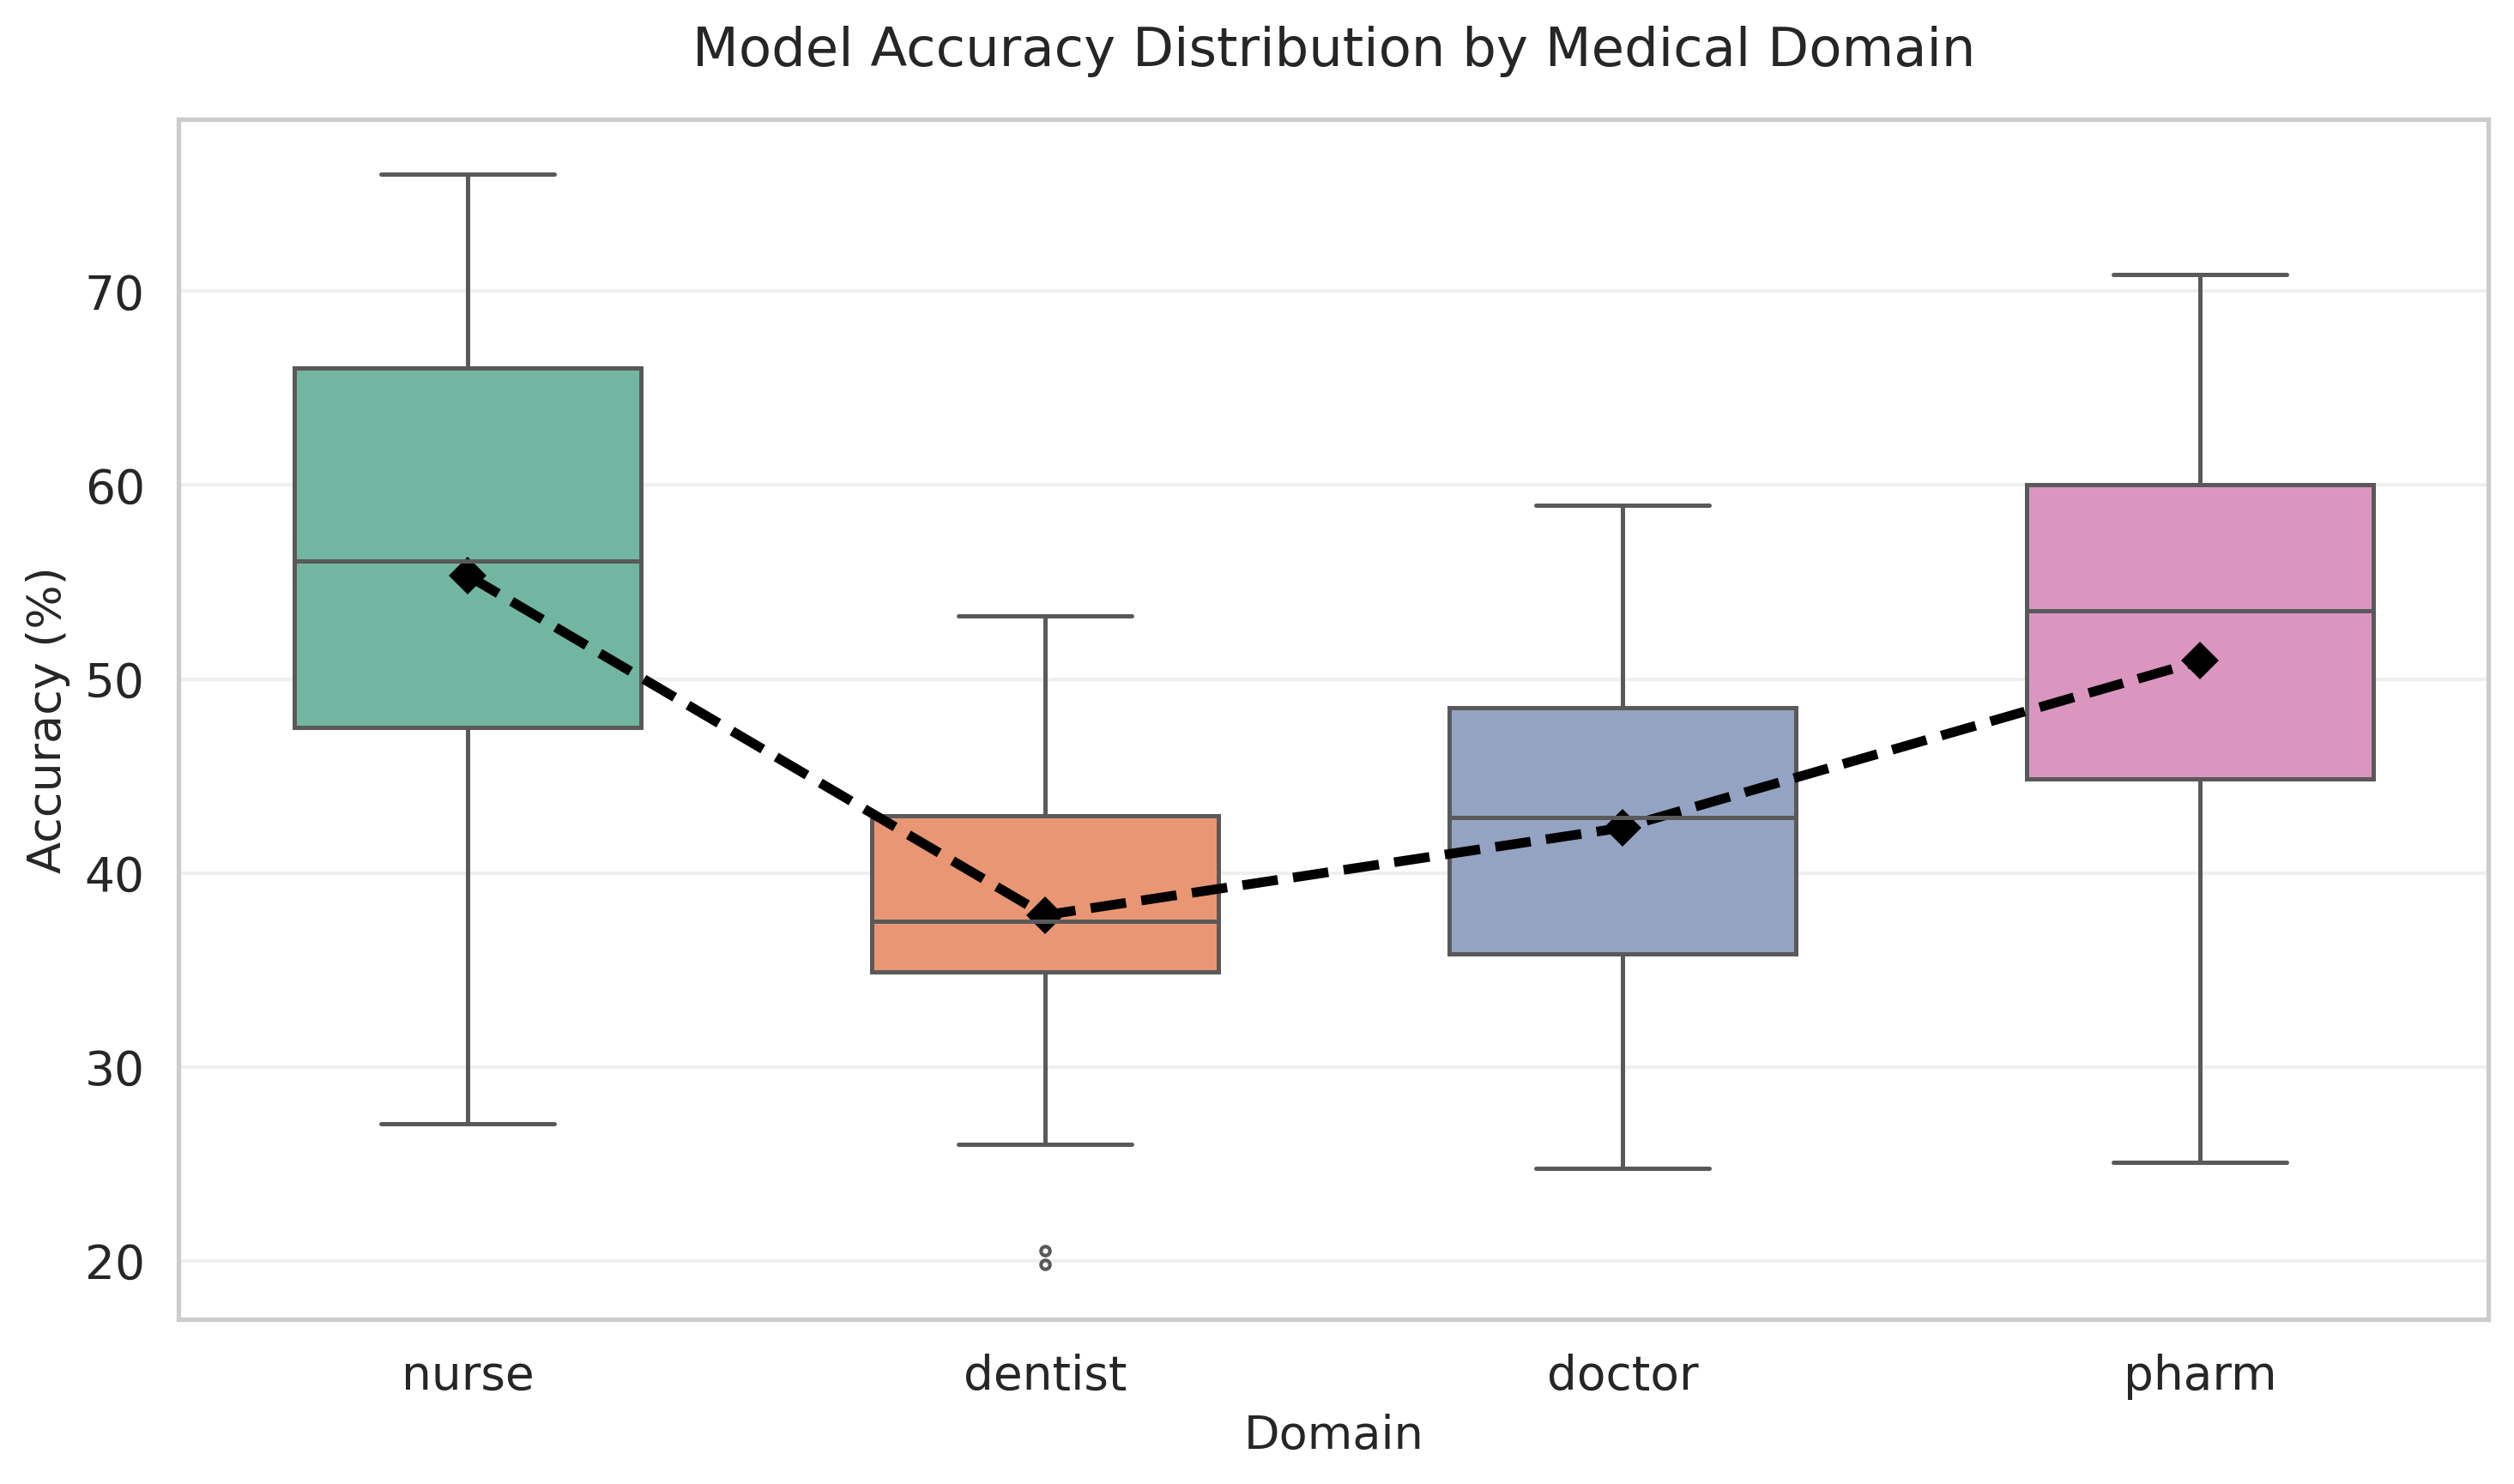

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# domain_dict 예시로부터 통합 DataFrame 생성
plot_df = pd.DataFrame()
for domain, df in domain_dict.items():
    temp = df[["model", "accuracy (%)"]].copy()
    temp["domain"] = domain
    plot_df = pd.concat([plot_df, temp])

# 스타일 설정 (논문용 미니멀한 디자인)
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Boxplot
ax = sns.boxplot(
    data=plot_df,
    x="domain",
    y="accuracy (%)",
    palette="Set2",
    linewidth=1.2,
    fliersize=2.5,  # outlier 점 크기
    width=0.6
)

# 각 도메인별 평균선 추가
sns.pointplot(
    data=plot_df,
    x="domain",
    y="accuracy (%)",
    estimator="mean",
    color="black",
    markers="D",
    linestyles="--",
    scale=1.0,
    errwidth=0,
)

# 축/레이블/디자인 다듬기
plt.title("Model Accuracy Distribution by Medical Domain", fontsize=15, pad=15)
plt.xlabel("Domain", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.tight_layout()

# 저장 옵션 (논문용 이미지)
plt.savefig("domain_accuracy_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
